# First orders analysis

🚀 We are finally ready to start analysing our `orders` dataset!

Our objective is to get an initial understanding of:
- `orders` properties
- their associated `review_scores`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import Modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Import your newly coded _order_ training set
from olist.order import Order

orders = Order().get_training_data(with_distance_seller_customer=False)

In [4]:
# Check your shape below

# Shape if you set with_distance_seller_customer=True
if orders.shape[1] == 13:
    assert(orders.shape == (95872, 13))

# Shape if you set with_distance_seller_customer=False
else:
    assert(orders.shape == (96353, 12))


## Inspect features

👉 Print summary statistics of each column of the order dataset (then focus in particular on `wait_time`)

In [5]:
orders.describe()

,wait_time,expected_wait_time,delay_vs_expected,dim_is_five_star,dim_is_one_star,review_score,number_of_items,number_of_sellers,price,freight_value
count,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000
mean,12.522869,23.741881,0.754903,0.592187,0.097610,4.155688,1.141687,1.013918,136.654623,22.757810
std,9.457183,8.759019,4.656481,0.491431,0.296788,1.284979,0.535362,0.123616,207.444085,21.496018
min,0.533414,2.008009,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.850000,0.000000
25%,6.763530,18.335243,0.000000,0.000000,0.000000,4.000000,1.000000,1.000000,45.900000,13.840000
50%,10.211944,23.233113,0.000000,1.000000,0.000000,5.000000,1.000000,1.000000,86.000000,17.160000
75%,15.685278,28.411979,0.000000,1.000000,0.000000,5.000000,1.000000,1.000000,149.900000,23.990000
max,208.351759,155.135463,188.975081,1.000000,1.000000,5.000000,21.000000,5.000000,13440.000000,1794.960000


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96353 entries, 0 to 96360
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            96353 non-null  object 
 1   wait_time           96353 non-null  float64
 2   expected_wait_time  96353 non-null  float64
 3   delay_vs_expected   96353 non-null  float64
 4   order_status        96353 non-null  object 
 5   dim_is_five_star    96353 non-null  int64  
 6   dim_is_one_star     96353 non-null  int64  
 7   review_score        96353 non-null  int64  
 8   number_of_items     96353 non-null  int64  
 9   number_of_sellers   96353 non-null  int64  
 10  price               96353 non-null  float64
 11  freight_value       96353 non-null  float64
dtypes: float64(5), int64(5), object(2)
memory usage: 9.6+ MB


📈 Plot histograms to get a sense of the distribution of each numerical feature.

----- Distribution of wait_time : -----


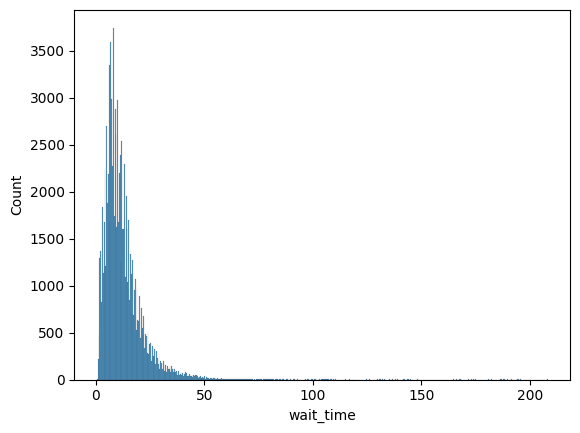

----- Distribution of expected_wait_time : -----


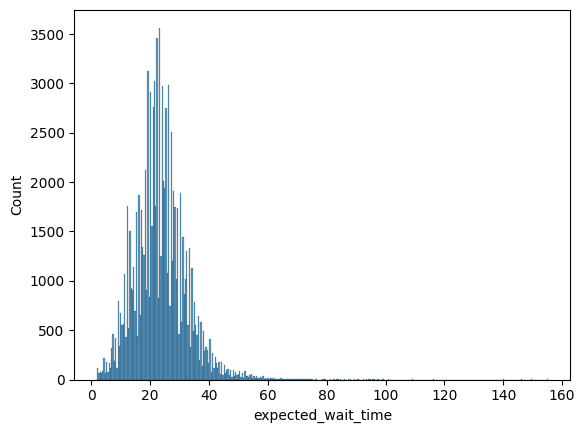

----- Distribution of delay_vs_expected : -----


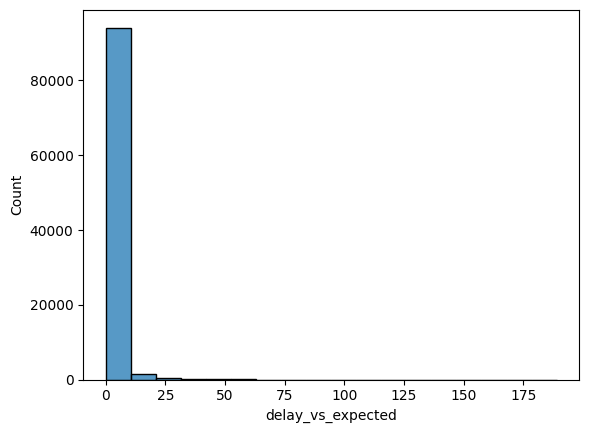

----- Distribution of dim_is_five_star : -----


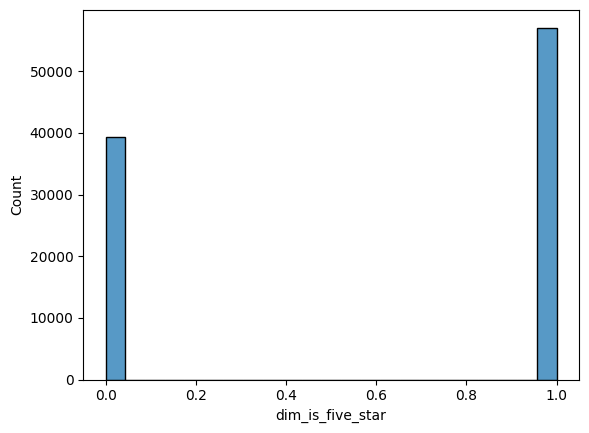

----- Distribution of dim_is_one_star : -----


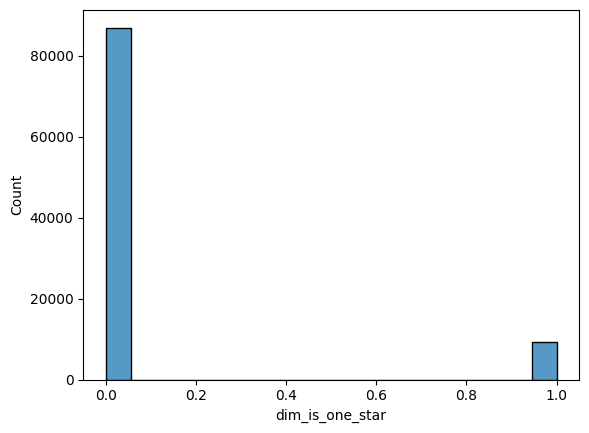

----- Distribution of review_score : -----


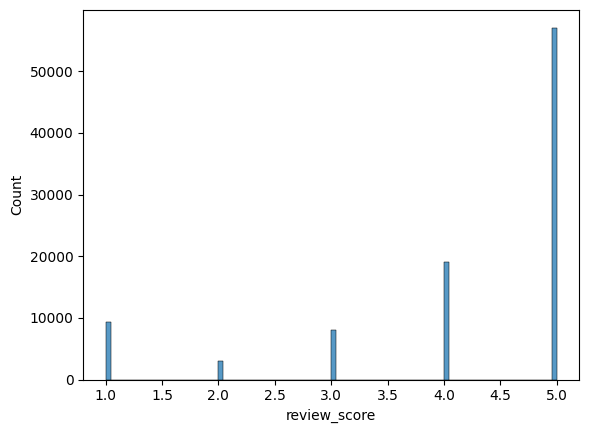

----- Distribution of number_of_items : -----


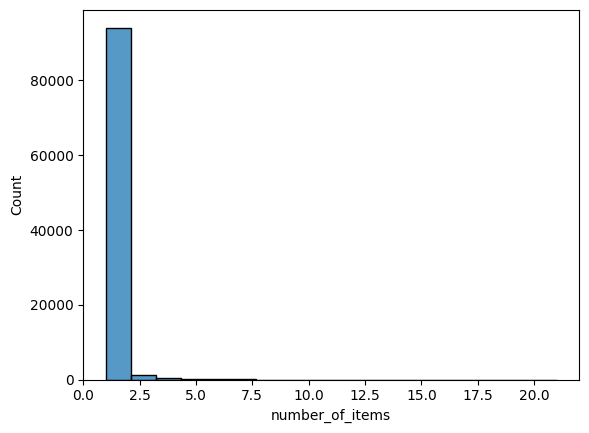

----- Distribution of number_of_sellers : -----


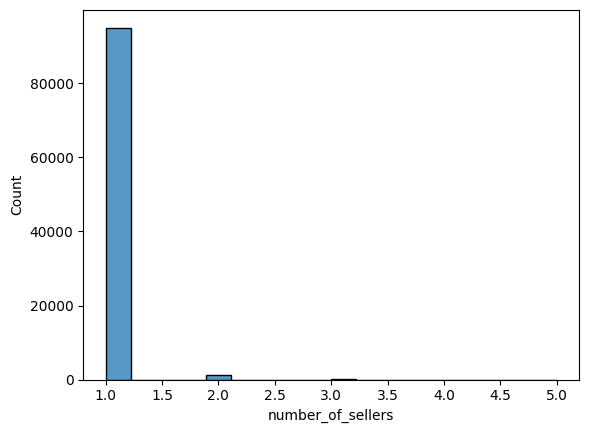

----- Distribution of price : -----


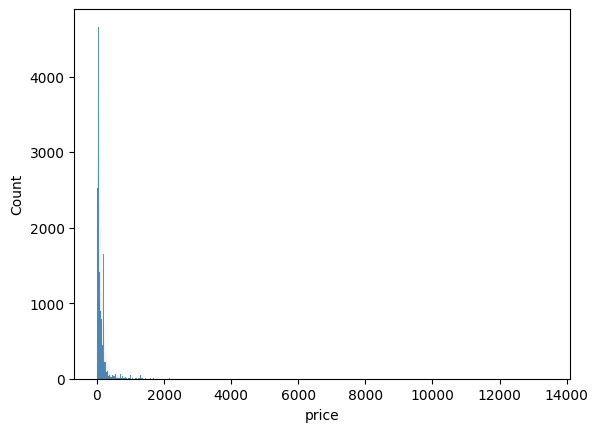

----- Distribution of freight_value : -----


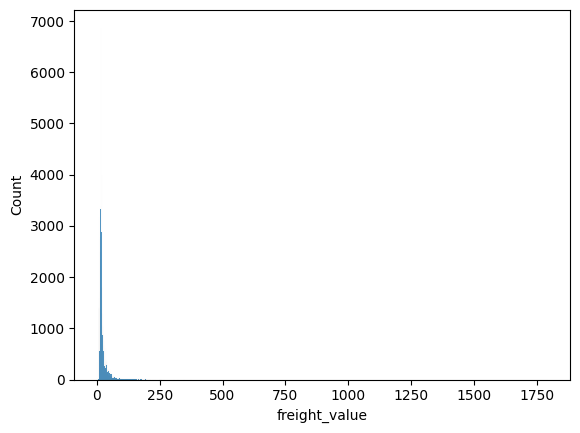

In [7]:
# Plot distribution for the numerical features  available in the dataset
for variable in orders.select_dtypes(exclude = ["object"]).columns:
    print(f"----- Distribution of {variable} : -----")
    sns.histplot(orders[variable])
    plt.show()

👀 In particular, create a `sns.FacetGrid()` of histograms for each `review_score` vs. `wait_time`

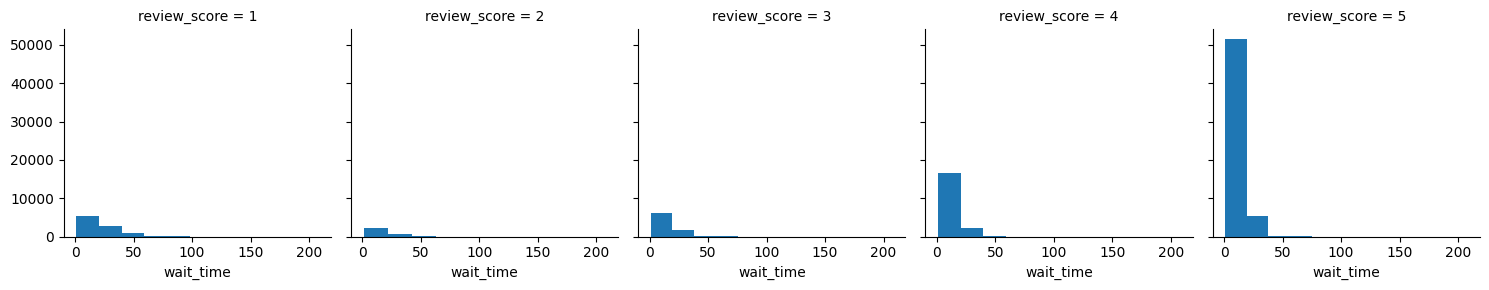

In [8]:
g = sns.FacetGrid(data=orders, col="review_score")
g.map(plt.hist, "wait_time");

❓ What do you notice for the variables `price` and `freight_value` ? 

❓ Have a look at the  `distance_seller_customer` feature if you have created it in `order.py`

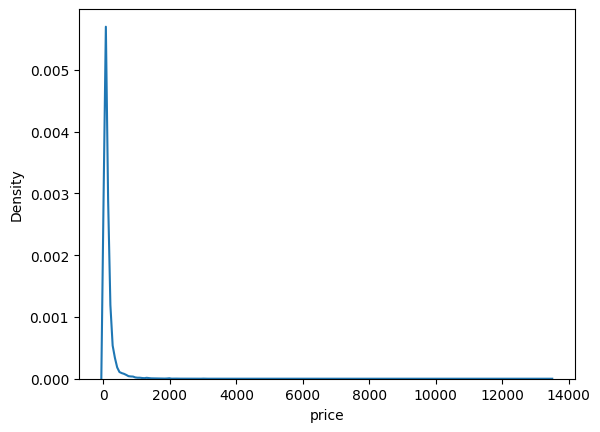

In [9]:
sns.kdeplot(orders['price']);

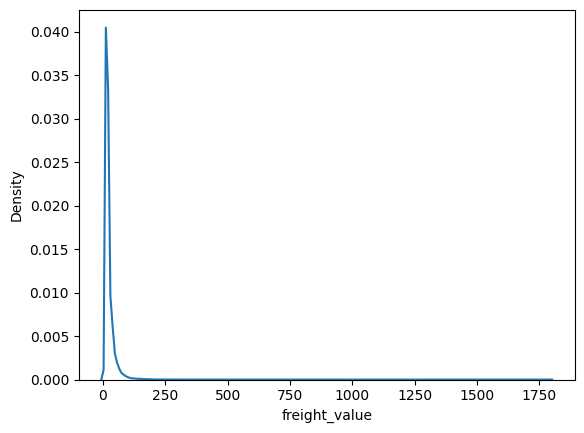

In [10]:
sns.kdeplot(orders['freight_value']);

In [11]:
if 'distance_seller_customer' in orders.columns:
    sns.kdeplot(orders['distance_seller_customer']);

❓Inspect the various correlations between features: which feature seems to the most correlated with `review_score`?

<details>
    <summary>▸ Hint</summary>

* Use `DataFrame.corr(numeric_only=True)` combined with `sns.heatmap()` and `cmap='coolwarm'`
* Have a look at the absolute values of the correlation coefficients of `review_score` vs. each feature,
    * the higher the coefficient, the more one given feature is correlated (positively or negatively) with the `review_score`

</details>

<Axes: >

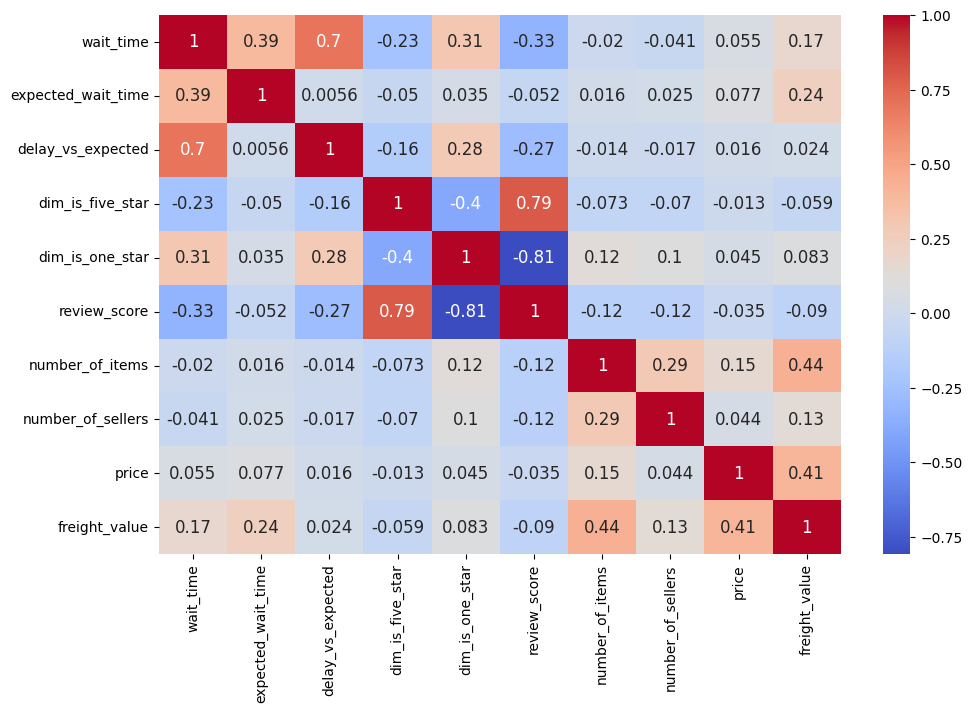

In [12]:
# Correlation plot
plt.figure(figsize=(11,7))
sns.heatmap(orders.corr(numeric_only=True), cmap='coolwarm', annot = True, annot_kws={"size": 12})


In [13]:
round(np.abs(orders.corr(numeric_only=True)['review_score']).sort_values(ascending = False),2)


review_score          1.00
dim_is_one_star       0.81
dim_is_five_star      0.79
wait_time             0.33
delay_vs_expected     0.27
number_of_items       0.12
number_of_sellers     0.12
freight_value         0.09
expected_wait_time    0.05
price                 0.03
Name: review_score, dtype: float64

In [14]:
round(orders.corr(numeric_only=True)['review_score'],2)


wait_time            -0.33
expected_wait_time   -0.05
delay_vs_expected    -0.27
dim_is_five_star      0.79
dim_is_one_star      -0.81
review_score          1.00
number_of_items      -0.12
number_of_sellers    -0.12
price                -0.03
freight_value        -0.09
Name: review_score, dtype: float64

* 😏 _Captain Obvious :_
    * `review_score` is 100% correlated to itself 
    * and strongly correlated to `dim_is_one_star` and `dim_is_five_star`...
* ⚠️ The two next highest correlation coefficients with respect to the `review_score` are :
    * `wait_time` : - 34 %
    * `delay_vs_expected` : - 27 %

---
🏁 Congratulations! 

🙏 Don't forget to `commit` and `push` your notebook